In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import shap

# Cargar los datos
df = pd.read_csv('dataset.csv')


# Ver estructura básica
print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras filas:\n{df.head()}")

# Ver distribución del target
print(f"\nDistribución del target:\n{df['target_variable'].value_counts()}")
print(f"Proporción: {df['target_variable'].value_counts(normalize=True)}")

# Ver valores nulos
print(f"\nValores nulos:\n{df.isnull().sum()}")

ModuleNotFoundError: No module named 'explainer'

In [3]:
# Eliminar columna id (no predictiva)
df = df.drop('id', axis=1)

# Separar features y target
X = df.drop('target_variable', axis=1)
y = df['target_variable']

# Dividir en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# Modelo base
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,           # Controla complejidad
    class_weight='balanced',  # Si hay desbalance
    random_state=42
)

# Entrenar
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_test)

# Calcular F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

# Reporte completo
print("\n" + "="*50)
print("Classification Report:")
print(classification_report(y_test, y_pred))

F1-Score: 0.7812

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79      3802
           1       0.75      0.81      0.78      3378

    accuracy                           0.79      7180
   macro avg       0.79      0.79      0.79      7180
weighted avg       0.79      0.79      0.79      7180



**Explainability**

In [12]:
# Opción más práctica - usar 1,000-2,000 muestras
X_test_shap = X_test[:2000]  # Primeras 2000 muestras
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_shap)

# Corrección: Extraer los SHAP values para la clase 1 (ganada) de todas las muestras y características.
# Si shap_values es un array 3D de forma (muestras, características, clases), usamos slicing avanzado.
shap_values_win = shap_values[:, :, 1]

print(f"✅ SHAP calculado para {len(X_test_shap)} muestras")
print(f"Dimensiones: {shap_values_win.shape}")

✅ SHAP calculado para 2000 muestras
Dimensiones: (2000, 15)


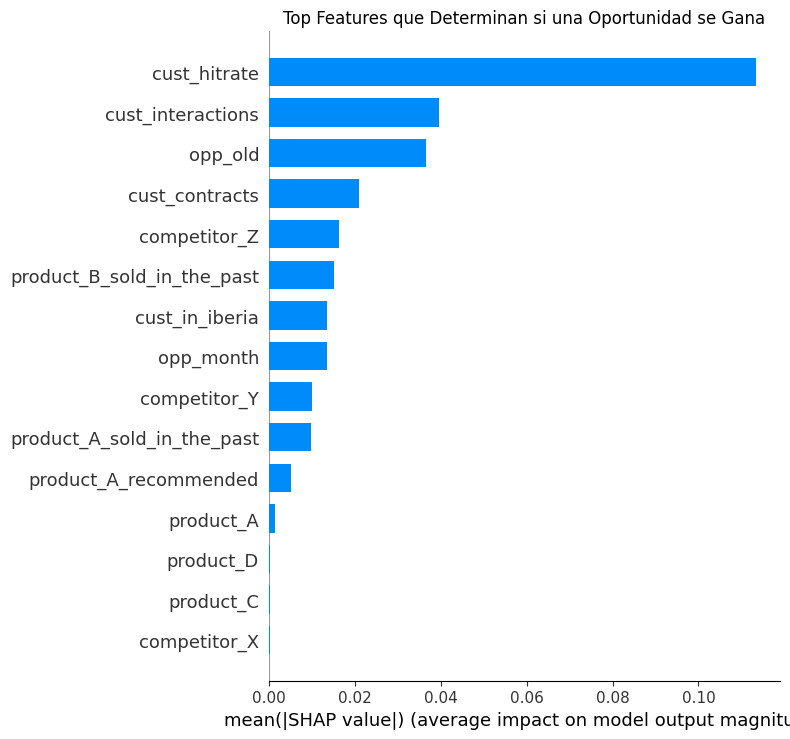

In [13]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_win, X_test_shap, plot_type="bar", show=False)
plt.title("Top Features que Determinan si una Oportunidad se Gana")
plt.tight_layout()
plt.show()